In [1]:
!pip install nltk spacy scikit-learn pandas matplotlib seaborn

In [2]:
import pandas as pd

df = pd.read_csv("customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [3]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [4]:
import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

In [9]:
df.rename(columns={
    'Ticket Description': 'ticket_text',
    'Ticket Type': 'category',
    'Ticket Priority': 'priority'
}, inplace=True)

In [10]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase', 'category',
       'Ticket Subject', 'ticket_text', 'Ticket Status', 'Resolution',
       'priority', 'Ticket Channel', 'First Response Time',
       'Time to Resolution', 'Customer Satisfaction Rating'],
      dtype='object')

In [11]:
df['clean_text'] = df['ticket_text'].apply(clean_text)

In [12]:
df[['ticket_text','clean_text']].head()

,ticket_text,clean_text
0,I'm having an issue with the {product_purchase...,issue product purchased please assist billing ...
1,I'm having an issue with the {product_purchase...,issue product purchased please assist need cha...
2,I'm facing a problem with my {product_purchase...,facing problem product purchased product purch...
3,I'm having an issue with the {product_purchase...,issue product purchased please assist problem ...
4,I'm having an issue with the {product_purchase...,issue product purchased please assist note sel...


In [13]:
df['category'].value_counts()

,count
category,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


In [14]:
df['priority'].value_counts()

,count
priority,
Medium,2192
Critical,2129
High,2085
Low,2063


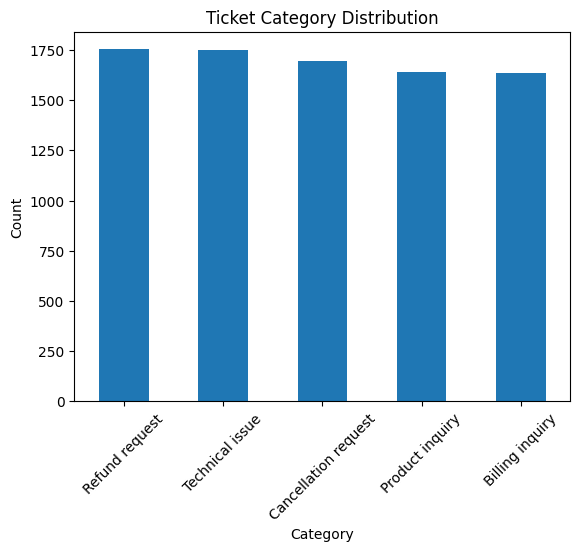

In [15]:
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar')

plt.title("Ticket Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

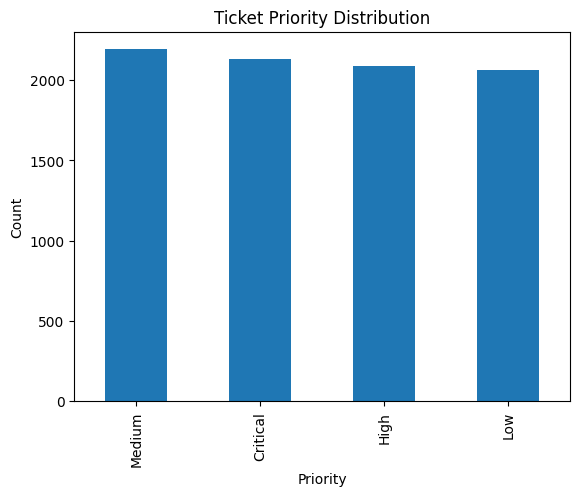

In [16]:
df['priority'].value_counts().plot(kind='bar')

plt.title("Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()

In [17]:
df['ticket_text'].sample(5)
df['ticket_text'].str.len().describe()

,ticket_text
count,8469.000000
mean,289.821939
std,43.593954
min,151.000000
25%,273.000000
50%,298.000000
75%,318.000000
max,397.000000


In [18]:
df['clean_text']

,clean_text
0,issue product purchased please assist billing ...
1,issue product purchased please assist need cha...
2,facing problem product purchased product purch...
3,issue product purchased please assist problem ...
4,issue product purchased please assist note sel...
...,...
8464,product purchased making strange noises functi...
8465,issue product purchased please assist sell als...
8466,issue product purchased please assist using di...
8467,issue product purchased please assist think pr...


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),   # single words + word pairs
    min_df=2             # ignore rare noise words
)

X = vectorizer.fit_transform(df['clean_text'])

In [20]:
X.shape

(8469, 5000)

In [21]:
y_category = df['category']
y_priority = df['priority']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X,
    y_category,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train_cat)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Results")
print(classification_report(y_test_cat, nb_pred))

Naive Bayes Results
                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.12      0.15       357
Cancellation request       0.19      0.19      0.19       327
     Product inquiry       0.17      0.18      0.17       316
      Refund request       0.19      0.21      0.20       345
     Technical issue       0.22      0.27      0.24       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.19      1694
        weighted avg       0.19      0.19      0.19      1694



In [24]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train_cat)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test_cat, lr_pred))

Logistic Regression Results
                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.14      0.17       357
Cancellation request       0.20      0.22      0.21       327
     Product inquiry       0.19      0.20      0.19       316
      Refund request       0.21      0.23      0.22       345
     Technical issue       0.24      0.26      0.25       349

            accuracy                           0.21      1694
           macro avg       0.21      0.21      0.21      1694
        weighted avg       0.21      0.21      0.21      1694



In [25]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train_cat)

svm_pred = svm_model.predict(X_test)

print("Linear SVM Results")
print(classification_report(y_test_cat, svm_pred))

Linear SVM Results
                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.16      0.17       357
Cancellation request       0.19      0.20      0.19       327
     Product inquiry       0.22      0.23      0.22       316
      Refund request       0.20      0.19      0.19       345
     Technical issue       0.22      0.23      0.23       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



In [26]:
df['combined_text'] = (
    df['Ticket Subject'] + " " + df['ticket_text']
)

In [27]:
df['clean_text'] = df['combined_text'].apply(clean_text)

In [28]:
X = vectorizer.fit_transform(df['clean_text'])

In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train_cat)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Results")
print(classification_report(y_test_cat, nb_pred))

Naive Bayes Results
                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.12      0.15       357
Cancellation request       0.19      0.19      0.19       327
     Product inquiry       0.17      0.18      0.17       316
      Refund request       0.19      0.21      0.20       345
     Technical issue       0.22      0.27      0.24       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.19      1694
        weighted avg       0.19      0.19      0.19      1694



In [31]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train_cat)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test_cat, lr_pred))

Logistic Regression Results
                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.13      0.15       357
Cancellation request       0.22      0.24      0.23       327
     Product inquiry       0.19      0.20      0.19       316
      Refund request       0.19      0.21      0.20       345
     Technical issue       0.24      0.25      0.24       349

            accuracy                           0.21      1694
           macro avg       0.20      0.21      0.20      1694
        weighted avg       0.20      0.21      0.20      1694



In [32]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train_cat)

svm_pred = svm_model.predict(X_test)

print("Linear SVM Results")
print(classification_report(y_test_cat, svm_pred))

Linear SVM Results
                      precision    recall  f1-score   support

     Billing inquiry       0.17      0.16      0.17       357
Cancellation request       0.19      0.20      0.19       327
     Product inquiry       0.20      0.22      0.21       316
      Refund request       0.20      0.18      0.19       345
     Technical issue       0.22      0.22      0.22       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



In [33]:
df['combined_text'] = (
    df['Ticket Subject'] + " " +
    df['Ticket Description'] + " " +
    df['Product Purchased']
)

df['clean_text'] = df['combined_text'].apply(clean_text)

vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),
    min_df=2
)

X_text = vectorizer.fit_transform(df['clean_text'])

KeyError: 'Ticket Description'

In [34]:
df['combined_text'] = (
    df['Ticket Subject'] + " " +
    df['ticket_text'] + " " +
    df['Product Purchased']
)


df['clean_text'] = df['combined_text'].apply(clean_text)



In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),
    min_df=2
)

X_text = vectorizer.fit_transform(df['clean_text'])

In [36]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

X_struct = encoder.fit_transform(
    df[['Ticket Channel']]
)

In [37]:
from scipy.sparse import hstack

X = hstack([X_text, X_struct])

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X,
    y_category,
    test_size=0.2,
    random_state=42
)

In [39]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train_cat)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Results")
print(classification_report(y_test_cat, nb_pred))

Naive Bayes Results
                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.07      0.10       357
Cancellation request       0.18      0.20      0.19       327
     Product inquiry       0.19      0.16      0.18       316
      Refund request       0.22      0.28      0.24       345
     Technical issue       0.20      0.26      0.22       349

            accuracy                           0.20      1694
           macro avg       0.19      0.20      0.19      1694
        weighted avg       0.19      0.20      0.19      1694



In [40]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train_cat)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test_cat, lr_pred))

Logistic Regression Results
                      precision    recall  f1-score   support

     Billing inquiry       0.17      0.13      0.15       357
Cancellation request       0.20      0.23      0.21       327
     Product inquiry       0.20      0.20      0.20       316
      Refund request       0.19      0.20      0.20       345
     Technical issue       0.21      0.22      0.22       349

            accuracy                           0.20      1694
           macro avg       0.19      0.20      0.19      1694
        weighted avg       0.19      0.20      0.19      1694



In [41]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train_cat)

svm_pred = svm_model.predict(X_test)

print("Linear SVM Results")
print(classification_report(y_test_cat, svm_pred))

Linear SVM Results
                      precision    recall  f1-score   support

     Billing inquiry       0.17      0.15      0.16       357
Cancellation request       0.18      0.20      0.19       327
     Product inquiry       0.23      0.25      0.24       316
      Refund request       0.21      0.21      0.21       345
     Technical issue       0.22      0.22      0.22       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



In [42]:
y_priority = df['priority']

X_train, X_test, y_train_pri, y_test_pri = train_test_split(
    X, y_priority, test_size=0.2, random_state=42
)

In [43]:
priority_model = LinearSVC()
priority_model.fit(X_train, y_train_pri)

pred_pri = priority_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test_pri, pred_pri))

              precision    recall  f1-score   support

    Critical       0.24      0.25      0.25       411
        High       0.25      0.27      0.26       409
         Low       0.23      0.23      0.23       415
      Medium       0.29      0.26      0.27       459

    accuracy                           0.25      1694
   macro avg       0.25      0.25      0.25      1694
weighted avg       0.25      0.25      0.25      1694



In [44]:
def rule_based_priority(text):
    text = text.lower()

    if "refund" in text or "payment" in text:
        return "High"

    if "error" in text or "not working" in text:
        return "Critical"

    return "Medium"

In [45]:
def final_priority(ticket):

    ml_pred = priority_model.predict(
        vectorizer.transform([clean_text(ticket)])
    )[0]

    rule_pred = rule_based_priority(ticket)

    if rule_pred == "Critical":
        return "Critical"

    return ml_pred

In [46]:
def rule_based_priority(text):

    text = text.lower()

    critical_keywords = [
        "payment failed",
        "refund not received",
        "account locked",
        "security issue",
        "system down"
    ]

    high_keywords = [
        "error",
        "not working",
        "unable",
        "failed"
    ]

    for word in critical_keywords:
        if word in text:
            return "Critical"

    for word in high_keywords:
        if word in text:
            return "High"

    return "Medium"

In [47]:
def predict_ticket(ticket):

    cleaned = clean_text(ticket)
    vect = vectorizer.transform([cleaned])

    category = svm_model.predict(vect)[0]
    ml_priority = priority_model.predict(vect)[0]
    rule_priority = rule_based_priority(ticket)

    if rule_priority == "Critical":
        final_priority = "Critical"
    else:
        final_priority = ml_priority

    print("Predicted Category:", category)
    print("Predicted Priority:", final_priority)

In [48]:
predict_ticket(
    "Payment deducted but subscription not activated"
)

ValueError: X has 8000 features, but LinearSVC is expecting 8004 features as input.

In [49]:
default_channel = "Email"

In [50]:
from scipy.sparse import hstack
import pandas as pd

def predict_ticket(ticket, channel="Email"):

    # ---- Text preprocessing ----
    cleaned = clean_text(ticket)
    text_vect = vectorizer.transform([cleaned])

    # ---- Structured feature encoding ----
    channel_df = pd.DataFrame([[channel]], columns=["Ticket Channel"])
    channel_vect = encoder.transform(channel_df)

    # ---- Combine features EXACTLY like training ----
    final_features = hstack([text_vect, channel_vect])

    # ---- Predictions ----
    category = svm_model.predict(final_features)[0]
    ml_priority = priority_model.predict(final_features)[0]
    rule_priority = rule_based_priority(ticket)

    if rule_priority == "Critical":
        final_priority = "Critical"
    else:
        final_priority = ml_priority

    print("Category:", category)
    print("Priority:", final_priority)

In [51]:
predict_ticket(
    "Payment deducted but subscription not activated",
    channel="Email"
)

Category: Technical issue
Priority: Critical


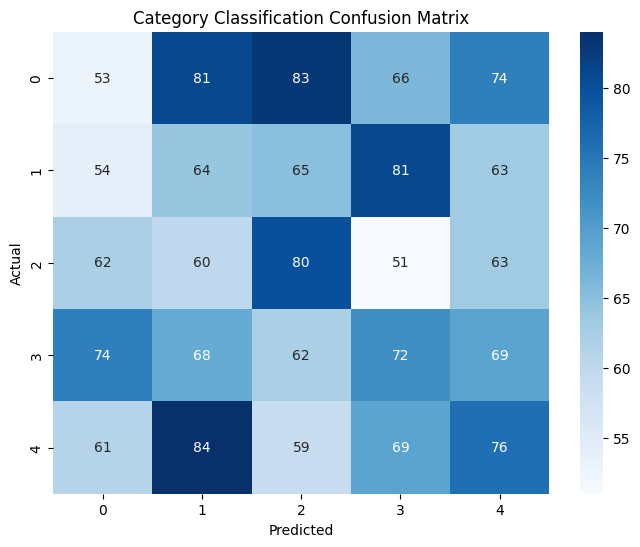

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_cat, svm_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Category Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

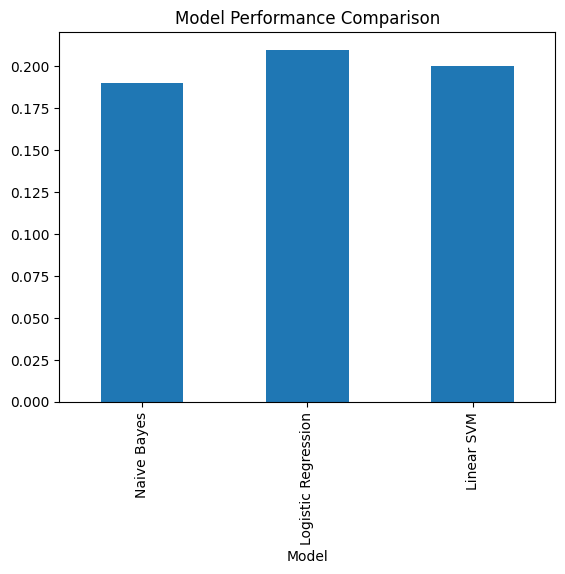

In [53]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Naive Bayes","Logistic Regression","Linear SVM"],
    "Accuracy": [0.19,0.21,0.20]
})

results.plot(x="Model", y="Accuracy", kind="bar", legend=False)
plt.title("Model Performance Comparison")
plt.show()